# Lab 6: Fuzzy Control Applications

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fuzzylite as fl
from fuzzylite import settings

# Register custom hedges to match lecture slide definitions
settings.factory_manager.hedge.constructors["slightly"] = lambda: fl.HedgeLambda("slightly", lambda x: x ** 1.7)
settings.factory_manager.hedge.constructors["more_or_less"] = lambda: fl.HedgeLambda("more_or_less", lambda x: x ** 0.5)
settings.factory_manager.hedge.constructors["a_little"] = lambda: fl.HedgeLambda("a_little", lambda x: x ** 1.3)
settings.factory_manager.hedge.constructors["extremely"] = lambda: fl.HedgeLambda("extremely", lambda x: x ** 3)
settings.factory_manager.hedge.constructors["very_very"] = lambda: fl.HedgeLambda("very_very", lambda x: x ** 4)

print(f"pyfuzzylite version: {fl.__version__}")
print(f"Available hedges: {list(settings.factory_manager.hedge.constructors.keys())}")


pyfuzzylite version: 8.0.6
Available hedges: ['any', 'extremely', 'not', 'seldom', 'somewhat', 'very', 'slightly', 'more_or_less', 'a_little', 'very_very']


## Plotting Helpers & Utility Functions

In [2]:
def get_output(engine, name):
    """Extract a scalar float from a fuzzy engine output variable.
    pyfuzzylite may return a numpy array instead of a plain float.
    This helper handles both cases safely.
    """
    val = engine.output_variable(name).value
    return float(val.item()) if hasattr(val, 'item') else float(val)


def plot_membership_functions(variable, title=None, ax=None):
    """Plot all membership functions for a pyfuzzylite variable."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3.5))
    x = np.linspace(variable.minimum, variable.maximum, 500)
    for term in variable.terms:
        y = np.array([float(term.membership(xi)) for xi in x])
        ax.plot(x, y, linewidth=2, label=term.name)
    ax.set_xlabel(variable.name)
    ax.set_ylabel('Membership Degree')
    ax.set_title(title or f'Membership Functions: {variable.name}')
    ax.legend(loc='best', fontsize=9)
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)
    return ax


def plot_simulation(times, speeds, throttles, errors, target, title="Cruise Control Response"):
    """Plot a 3-panel time-domain response for a control simulation."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(times, speeds, 'b-', linewidth=1.5, label='Actual Speed')
    axes[0].axhline(y=target, color='r', linestyle='--', linewidth=1, label=f'Target ({target} km/h)')
    axes[0].set_ylabel('Speed (km/h)')
    axes[0].legend(loc='best')
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(times, throttles, 'g-', linewidth=1.5)
    axes[1].axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
    axes[1].set_ylabel('Throttle')
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(times, errors, 'r-', linewidth=1.5)
    axes[2].axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
    axes[2].set_ylabel('Speed Error (km/h)')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_comparison(times, speed_dict, target, title="Controller Comparison"):
    """Overlay multiple speed traces for comparison."""
    plt.figure(figsize=(10, 5))
    for label, speeds in speed_dict.items():
        plt.plot(times, speeds, linewidth=1.5, label=label)
    plt.axhline(y=target, color='r', linestyle='--', linewidth=1, label=f'Target ({target} km/h)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Speed (km/h)')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_control_surface(engine, input1_name, input2_name, output_name, resolution=50):
    """Generate and plot the 3D control surface for a 2-input, 1-output fuzzy system."""
    iv1 = engine.input_variable(input1_name)
    iv2 = engine.input_variable(input2_name)
    x1 = np.linspace(iv1.minimum, iv1.maximum, resolution)
    x2 = np.linspace(iv2.minimum, iv2.maximum, resolution)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)
    for i in range(len(x2)):
        for j in range(len(x1)):
            iv1.value = float(x1[j])
            iv2.value = float(x2[i])
            engine.process()
            Z[i, j] = get_output(engine, output_name)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X1, X2, Z, cmap='RdYlGn', edgecolor='none', alpha=0.85)
    ax.set_xlabel(input1_name)
    ax.set_ylabel(input2_name)
    ax.set_zlabel(output_name)
    ax.set_title(f'Control Surface: {engine.name}')
    fig.colorbar(surf, shrink=0.5, aspect=10, label=output_name)
    plt.tight_layout()
    plt.show()
    return X1, X2, Z


print("Plotting helpers loaded.")


Plotting helpers loaded.


## Exercise 1: The Car Plant Model

### 1.1 — Implement the Plant

In [3]:
# Car dynamics:
#   Drag force:       proportional to speed² (aerodynamic resistance)
#   Throttle force:   proportional to the controller's output
#   External forces:  hills (gravity component), headwinds
#
# At each time step, Newton's second law gives us:
#
# 1.1 — Implement the Plant
# Complete the CarPlant class below. The step() method should:
#   1. Compute the drag force from the current speed
#   2. Compute the net force (throttle − drag − disturbance)
#   3. Update the speed using acceleration = net_force / mass
#   4. Return the new speed


class CarPlant:
    """Simple car dynamics for cruise control simulation."""

    def __init__(self, mass=1200, drag_coeff=0.3, force_gain=30, dt=0.1):
        self.mass = mass              # kg
        self.drag_coeff = drag_coeff  # aerodynamic drag coefficient
        self.force_gain = force_gain  # Newtons per unit of throttle output
        self.dt = dt                  # simulation time step (seconds)
        self.speed = 0.0              # current speed in km/h
        self.prev_speed = 0.0         # previous speed (for acceleration calc)

    def reset(self, initial_speed):
        """Reset the plant to a given initial speed."""
        self.speed = initial_speed
        self.prev_speed = initial_speed

    def step(self, throttle, disturbance=0.0):
        """
        Advance one time step.

        Parameters
        ----------
        throttle : float
            Controller output (can be negative for braking).
        disturbance : float
            External force in Newtons (e.g. hill gravity, headwind).

        Returns
        -------
        speed : float
            Updated speed in km/h.
        """
        self.prev_speed = self.speed

        # Compute throttle force
        throttle_force = throttle * self.force_gain

        # Compute speed in m/s (divide km/h by 3.6)
        speed_ms = self.speed / 3.6

        # Compute drag force
        drag_force = self.drag_coeff * speed_ms ** 2

        # Compute net force
        net_force = throttle_force - drag_force - disturbance

        # Compute acceleration
        acceleration_ms2 = net_force / self.mass

        speed_change_kmh = acceleration_ms2 * self.dt * 3.6  # convert m/s² back to km/h change
        self.speed = max(0.0, self.speed + speed_change_kmh)
        return self.speed

    def get_acceleration(self):
        """Return acceleration in km/h per second."""
        return (self.speed - self.prev_speed) / self.dt


### 1.2 — Test Without a Controller

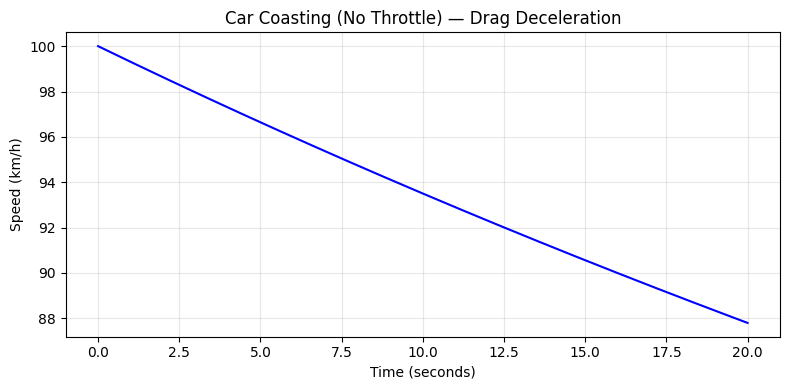

Speed after 20s: 87.80 km/h


In [4]:
plant = CarPlant()
plant.reset(100.0)

times_coast = [0.0]
speeds_coast = [100.0]

for step in range(1, 201):
    t = step * plant.dt
    speed = plant.step(throttle=0.0)
    times_coast.append(t)
    speeds_coast.append(speed)

plt.figure(figsize=(8, 4))
plt.plot(times_coast, speeds_coast, 'b-', linewidth=1.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (km/h)')
plt.title('Car Coasting (No Throttle) — Drag Deceleration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Speed after 20s: {speeds_coast[-1]:.2f} km/h")


## Exercise 2: Build the Mamdani Cruise Controller

### 2.1 — Define the Fuzzy Inference System

In [5]:
def create_mamdani_cruise_controller():
    """Create a Mamdani fuzzy cruise controller."""
    engine = fl.Engine(
        name="CruiseControl_Mamdani",
        input_variables=[
            fl.InputVariable(
                name="speed_error", minimum=-30, maximum=30,
                terms=[
                    fl.Trapezoid("large_negative", -30, -30, -15, -5),
                    fl.Triangle("small_negative", -10, -5, 0),
                    fl.Triangle("zero", -5, 0, 5),
                    fl.Triangle("small_positive", 0, 5, 10),
                    fl.Trapezoid("large_positive", 5, 15, 30, 30),
                ],
            ),
            fl.InputVariable(
                name="acceleration", minimum=-5, maximum=5,
                terms=[
                    fl.Trapezoid("braking",      -5, -5, -2,  0),
                    fl.Triangle("steady",         -2,  0,  2),
                    fl.Trapezoid("accelerating",   0,  2,  5,  5),
                ],
            ),
        ],
        output_variables=[
            fl.OutputVariable(
                name="throttle", minimum=-50, maximum=50,
                aggregation=fl.Maximum(),
                defuzzifier=fl.Centroid(200),
                terms=[
                    fl.Trapezoid("brake_hard",       -50, -50, -30, -10),
                    fl.Triangle("brake_light",        -20, -10,   0),
                    fl.Triangle("maintain",            -5,   0,   5),
                    fl.Triangle("accelerate_light",     0,  10,  20),
                    fl.Trapezoid("accelerate_hard",    10,  30,  50, 50),
                ],
            ),
        ],
        rule_blocks=[
            fl.RuleBlock(
                name="rules",
                conjunction=fl.Minimum(),
                disjunction=fl.Maximum(),
                implication=fl.Minimum(),
                activation=fl.General(),
                rules=[
                    fl.Rule.create("if speed_error is large_negative then throttle is brake_hard"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is accelerating then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is steady then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is braking then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero then throttle is maintain"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is steady then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is accelerating then throttle is maintain"),
                    fl.Rule.create("if speed_error is large_positive then throttle is accelerate_hard"),
                ],
            ),
        ],
    )
    return engine


mamdani = create_mamdani_cruise_controller()
print(f"Engine: {mamdani.name}, Rules: {len(mamdani.rule_blocks[0].rules)}")


Engine: CruiseControl_Mamdani, Rules: 9


### 2.2 — Visualise the Membership Functions

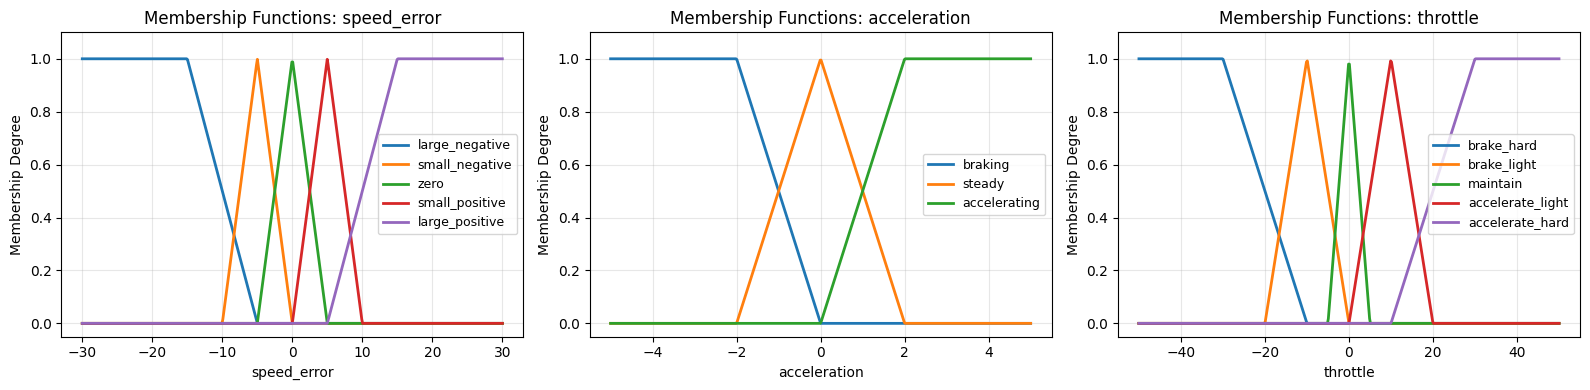

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_membership_functions(mamdani.input_variable("speed_error"), ax=axes[0])
plot_membership_functions(mamdani.input_variable("acceleration"), ax=axes[1])
plot_membership_functions(mamdani.output_variable("throttle"), ax=axes[2])
plt.tight_layout()
plt.show()

### 2.3 — Quick Sanity Check

In [7]:
test_cases = [
    (20.0,   0.0, "Too slow, steady"),
    (-15.0,  2.0, "Too fast, still accelerating"),
    (3.0,   -1.0, "Slightly slow, decelerating"),
    (0.0,    0.0, "On target, steady"),
]

print(f"{'Description':<35} {'Error':>6} {'Accel':>6} {'Throttle':>10}")
print("-" * 62)

for err, acc, desc in test_cases:
    mamdani.input_variable("speed_error").value = err
    mamdani.input_variable("acceleration").value = acc
    mamdani.process()
    throttle = get_output(mamdani, "throttle")
    print(f"{desc:<35} {err:>6.1f} {acc:>6.1f} {throttle:>10.2f}")


Description                          Error  Accel   Throttle
--------------------------------------------------------------
Too slow, steady                      20.0    0.0      34.44
Too fast, still accelerating         -15.0    2.0     -34.44
Slightly slow, decelerating            3.0   -1.0       7.37
On target, steady                      0.0    0.0       0.00


## Exercise 3: Closed-Loop Simulation

### 3.1 — Run the Control Loop

In [8]:
def run_simulation(engine, plant, target_speed, initial_speed, n_steps=500, disturbance_fn=None):
    """
    Run a closed-loop fuzzy control simulation.

    Parameters
    ----------
    engine : fl.Engine
        The fuzzy inference engine (controller).
    plant : CarPlant
        The plant model.
    target_speed : float
        Desired speed in km/h.
    initial_speed : float
        Starting speed in km/h.
    n_steps : int
        Number of simulation steps.
    disturbance_fn : callable or None
        A function f(t) -> force (Newtons) for external disturbances.

    Returns
    -------
    dict with keys: 'times', 'speeds', 'throttles', 'errors'
    """
    plant.reset(initial_speed)
    times     = [0.0]
    speeds    = [initial_speed]
    throttles = [0.0]
    errors    = [target_speed - initial_speed]

    for step in range(1, n_steps + 1):
        t            = step * plant.dt
        speed_error  = target_speed - plant.speed
        acceleration = plant.get_acceleration()

        se_clamped = np.clip(speed_error,  -30, 30)
        ac_clamped = np.clip(acceleration,  -5,  5)

        engine.input_variable("speed_error").value  = float(se_clamped)
        engine.input_variable("acceleration").value = float(ac_clamped)
        engine.process()

        throttle  = get_output(engine, "throttle")
        dist      = disturbance_fn(t) if disturbance_fn else 0.0
        new_speed = plant.step(throttle, disturbance=dist)

        times.append(t)
        speeds.append(new_speed)
        throttles.append(throttle)
        errors.append(target_speed - new_speed)

    return {'times': times, 'speeds': speeds, 'throttles': throttles, 'errors': errors}

### 3.2 — Acceleration from 60 to 100 km/h

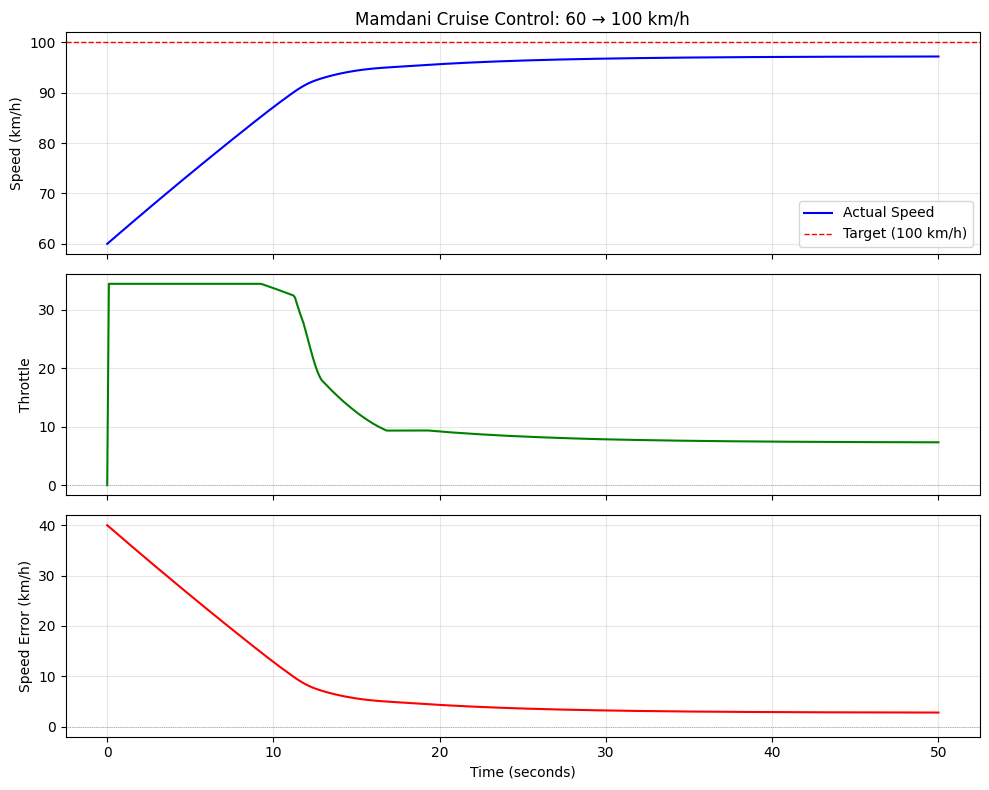

Final speed:          97.20 km/h
Steady-state error:   2.80 km/h
Max overshoot:        -2.80 km/h


In [9]:
plant = CarPlant()
result = run_simulation(mamdani, plant, target_speed=100, initial_speed=60, n_steps=500)

plot_simulation(result['times'], result['speeds'], result['throttles'], result['errors'],
                target=100, title='Mamdani Cruise Control: 60 → 100 km/h')

# Performance metrics
final_speed       = result['speeds'][-1]
steady_state_error = 100 - final_speed
max_speed         = max(result['speeds'])
overshoot         = max_speed - 100

print(f"Final speed:          {final_speed:.2f} km/h")
print(f"Steady-state error:   {steady_state_error:.2f} km/h")
print(f"Max overshoot:        {overshoot:.2f} km/h")


### 3.3 — Observe the Steady-State Error

**Question: How might you fix the steady-state error? Two approaches:**

1. **Shift the output membership functions** — Move the "maintain" term so its centroid maps to a small positive throttle value (e.g., centred at ~5 instead of 0). This compensates for the constant drag offset at cruising speed, so the controller naturally outputs enough throttle to hold speed even when the error is in the "zero" region.

2. **Add an integral term (hybrid fuzzy-PI)** — Accumulate the speed error over time and add a small correction proportional to the integral to the fuzzy output. This is analogous to the I-term in a PID controller and will drive residual steady-state error to zero regardless of drag.


## Exercise 4: Disturbance Rejection

### 4.1 — Hill Disturbance

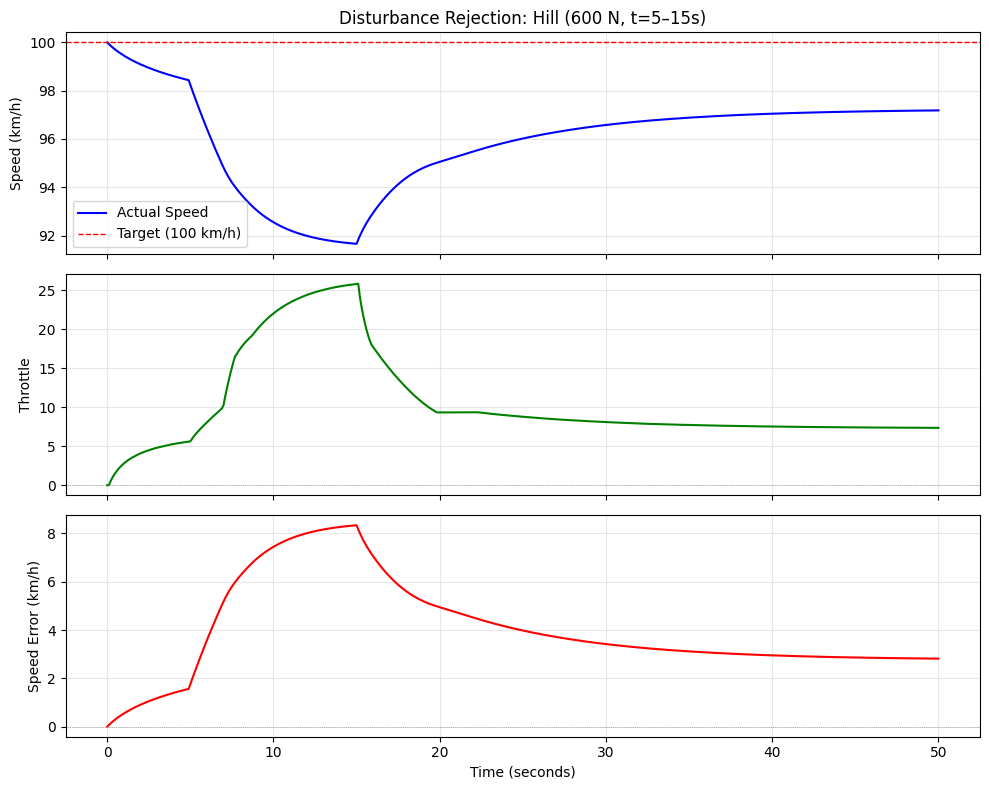

Minimum speed during hill: 91.66 km/h
Speed drop:                8.34 km/h
Final speed (after hill):  97.18 km/h


In [10]:
def hill_disturbance(t):
    """600 N opposing force between t=5 and t=15 seconds."""
    return 600.0 if 5 <= t <= 15 else 0.0


plant = CarPlant()
result_hill = run_simulation(
    mamdani, plant,
    target_speed=100,
    initial_speed=100,
    n_steps=500,
    disturbance_fn=hill_disturbance,
)

plot_simulation(result_hill['times'], result_hill['speeds'], result_hill['throttles'],
                result_hill['errors'], target=100, title='Disturbance Rejection: Hill (600 N, t=5–15s)')

min_speed = min(result_hill['speeds'])
print(f"Minimum speed during hill: {min_speed:.2f} km/h")
print(f"Speed drop:                {100 - min_speed:.2f} km/h")
print(f"Final speed (after hill):  {result_hill['speeds'][-1]:.2f} km/h")


### 4.2 — Wind Gust Disturbance

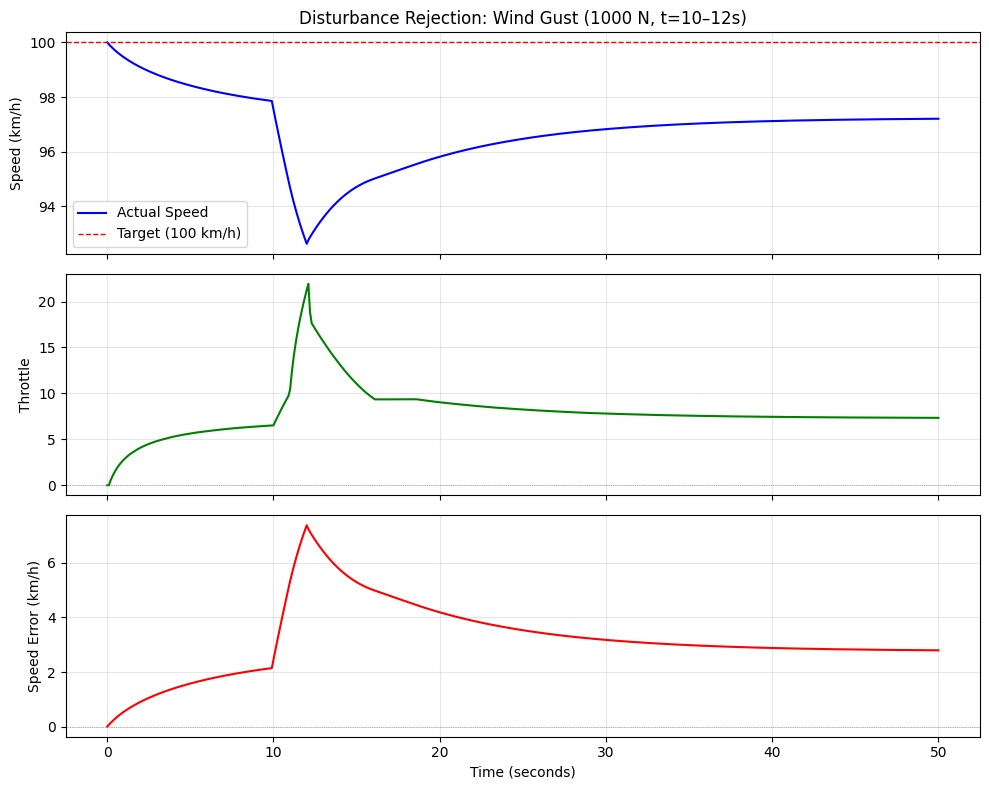

Minimum speed during gust: 92.62 km/h
Speed drop:                7.38 km/h
Final speed (after gust):  97.20 km/h


In [11]:
def wind_gust(t):
    """1000 N opposing force between t=10 and t=12 seconds."""
    return 1000.0 if 10 <= t <= 12 else 0.0


plant = CarPlant()
result_wind = run_simulation(
    mamdani, plant,
    target_speed=100,
    initial_speed=100,
    n_steps=500,
    disturbance_fn=wind_gust,
)

plot_simulation(result_wind['times'], result_wind['speeds'], result_wind['throttles'],
                result_wind['errors'], target=100, title='Disturbance Rejection: Wind Gust (1000 N, t=10–12s)')

min_speed_wind = min(result_wind['speeds'])
print(f"Minimum speed during gust: {min_speed_wind:.2f} km/h")
print(f"Speed drop:                {100 - min_speed_wind:.2f} km/h")
print(f"Final speed (after gust):  {result_wind['speeds'][-1]:.2f} km/h")


## Exercise 5: Controller Tuning

### 5.1 — Strategy A: Shift the "maintain" Output

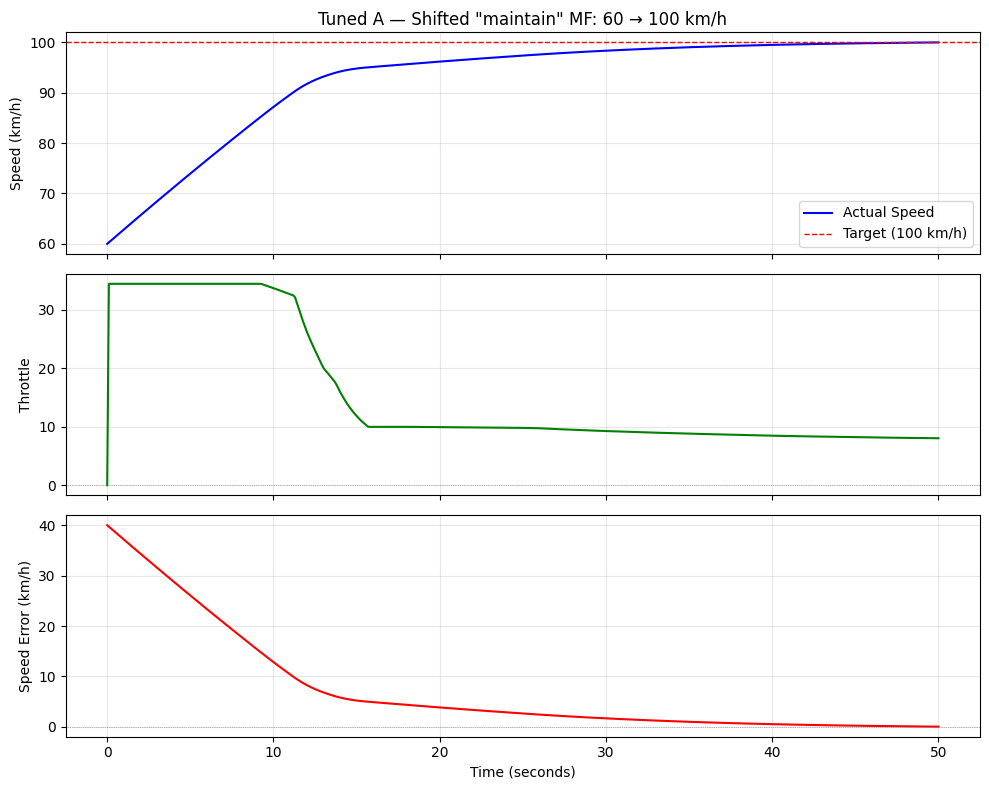

Tuned A — Final speed: 99.97 km/h, SSE: 0.03 km/h


In [12]:
def create_tuned_controller_A():
    """Mamdani controller with the 'maintain' term shifted to compensate for drag."""
    engine = fl.Engine(
        name="CruiseControl_TunedA",
        input_variables=[
            fl.InputVariable(
                name="speed_error", minimum=-30, maximum=30,
                terms=[
                    fl.Trapezoid("large_negative", -30, -30, -15, -5),
                    fl.Triangle("small_negative",   -10,  -5,   0),
                    fl.Triangle("zero",               -5,   0,   5),
                    fl.Triangle("small_positive",      0,   5,  10),
                    fl.Trapezoid("large_positive",     5,  15,  30, 30),
                ],
            ),
            fl.InputVariable(
                name="acceleration", minimum=-5, maximum=5,
                terms=[
                    fl.Trapezoid("braking",      -5, -5, -2,  0),
                    fl.Triangle("steady",         -2,  0,  2),
                    fl.Trapezoid("accelerating",   0,  2,  5,  5),
                ],
            ),
        ],
        output_variables=[
            fl.OutputVariable(
                name="throttle", minimum=-50, maximum=50,
                aggregation=fl.Maximum(),
                defuzzifier=fl.Centroid(200),
                terms=[
                    fl.Trapezoid("brake_hard",       -50, -50, -30, -10),
                    fl.Triangle("brake_light",        -20, -10,   0),
                    fl.Triangle("maintain",             0,   8,  16),  # shifted right to compensate drag
                    fl.Triangle("accelerate_light",     0,  10,  20),
                    fl.Trapezoid("accelerate_hard",    10,  30,  50, 50),
                ],
            ),
        ],
        rule_blocks=[
            fl.RuleBlock(
                name="rules",
                conjunction=fl.Minimum(),
                disjunction=fl.Maximum(),
                implication=fl.Minimum(),
                activation=fl.General(),
                rules=[
                    fl.Rule.create("if speed_error is large_negative then throttle is brake_hard"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is accelerating then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is steady then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is braking then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero then throttle is maintain"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is steady then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is accelerating then throttle is maintain"),
                    fl.Rule.create("if speed_error is large_positive then throttle is accelerate_hard"),
                ],
            ),
        ],
    )
    return engine


tuned_a = create_tuned_controller_A()
plant = CarPlant()
result_a = run_simulation(tuned_a, plant, target_speed=100, initial_speed=60, n_steps=500)

plot_simulation(result_a['times'], result_a['speeds'], result_a['throttles'], result_a['errors'],
                target=100, title='Tuned A — Shifted "maintain" MF: 60 → 100 km/h')

print(f"Tuned A — Final speed: {result_a['speeds'][-1]:.2f} km/h, "
      f"SSE: {100 - result_a['speeds'][-1]:.2f} km/h")


### 5.2 — Strategy B: Expand the "zero" Rules

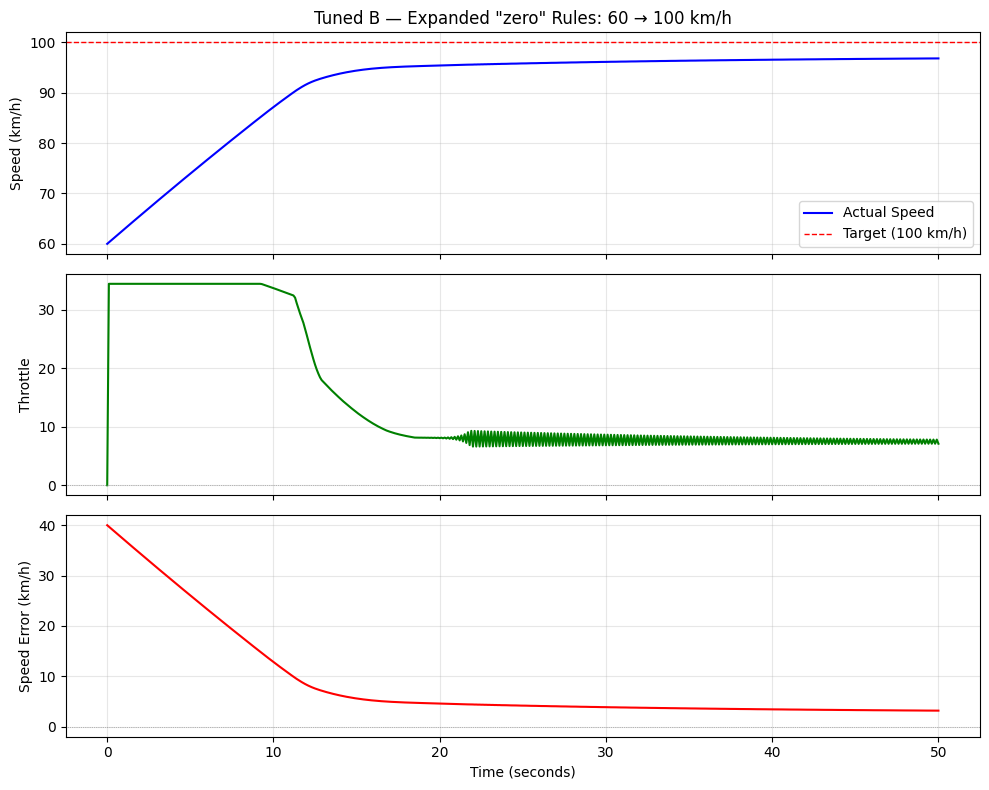

Tuned B — Final speed: 96.82 km/h, SSE: 3.18 km/h


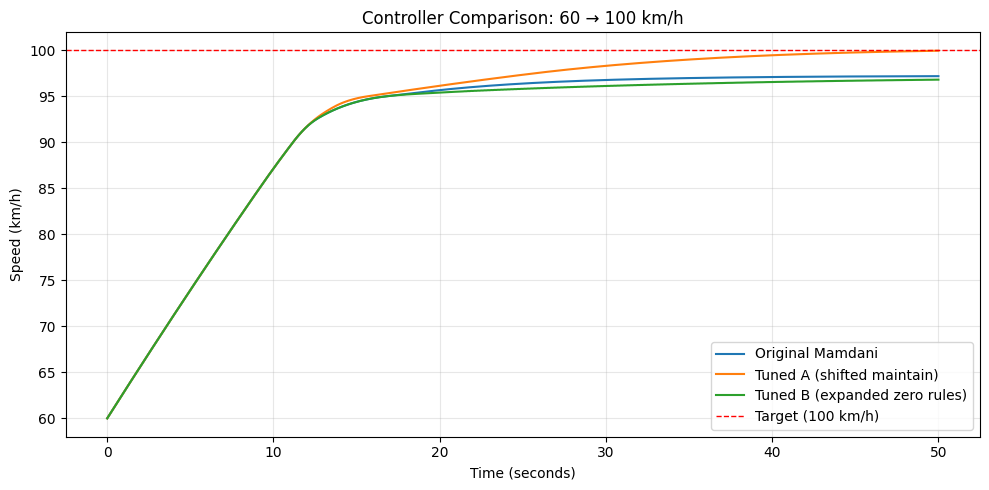

In [13]:
def create_tuned_controller_B():
    """Mamdani controller with expanded 'zero' rules to handle drag at steady state."""
    engine = fl.Engine(
        name="CruiseControl_TunedB",
        input_variables=[
            fl.InputVariable(
                name="speed_error", minimum=-30, maximum=30,
                terms=[
                    fl.Trapezoid("large_negative", -30, -30, -15, -5),
                    fl.Triangle("small_negative",   -10,  -5,   0),
                    fl.Triangle("zero",               -5,   0,   5),
                    fl.Triangle("small_positive",      0,   5,  10),
                    fl.Trapezoid("large_positive",     5,  15,  30, 30),
                ],
            ),
            fl.InputVariable(
                name="acceleration", minimum=-5, maximum=5,
                terms=[
                    fl.Trapezoid("braking",      -5, -5, -2,  0),
                    fl.Triangle("steady",         -2,  0,  2),
                    fl.Trapezoid("accelerating",   0,  2,  5,  5),
                ],
            ),
        ],
        output_variables=[
            fl.OutputVariable(
                name="throttle", minimum=-50, maximum=50,
                aggregation=fl.Maximum(),
                defuzzifier=fl.Centroid(200),
                terms=[
                    fl.Trapezoid("brake_hard",       -50, -50, -30, -10),
                    fl.Triangle("brake_light",        -20, -10,   0),
                    fl.Triangle("maintain",            -5,   0,   5),
                    fl.Triangle("accelerate_light",     0,  10,  20),
                    fl.Trapezoid("accelerate_hard",    10,  30,  50, 50),
                ],
            ),
        ],
        rule_blocks=[
            fl.RuleBlock(
                name="rules",
                conjunction=fl.Minimum(),
                disjunction=fl.Maximum(),
                implication=fl.Minimum(),
                activation=fl.General(),
                rules=[
                    # Original rules
                    fl.Rule.create("if speed_error is large_negative then throttle is brake_hard"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is accelerating then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is steady then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is braking then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero then throttle is maintain"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is steady then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is accelerating then throttle is maintain"),
                    fl.Rule.create("if speed_error is large_positive then throttle is accelerate_hard"),
                    # Extra "zero" rules — respond to drag-induced deceleration at steady state
                    fl.Rule.create("if speed_error is zero and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is zero and acceleration is steady then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero and acceleration is accelerating then throttle is brake_light"),
                ],
            ),
        ],
    )
    return engine


tuned_b = create_tuned_controller_B()
plant = CarPlant()
result_b = run_simulation(tuned_b, plant, target_speed=100, initial_speed=60, n_steps=500)

plot_simulation(result_b['times'], result_b['speeds'], result_b['throttles'], result_b['errors'],
                target=100, title='Tuned B — Expanded "zero" Rules: 60 → 100 km/h')

print(f"Tuned B — Final speed: {result_b['speeds'][-1]:.2f} km/h, "
      f"SSE: {100 - result_b['speeds'][-1]:.2f} km/h")

# Comparison
plot_comparison(
    result['times'],
    {
        'Original Mamdani': result['speeds'],
        'Tuned A (shifted maintain)': result_a['speeds'],
        'Tuned B (expanded zero rules)': result_b['speeds'],
    },
    target=100,
    title='Controller Comparison: 60 → 100 km/h',
)


### 5.3 — Compare All Three

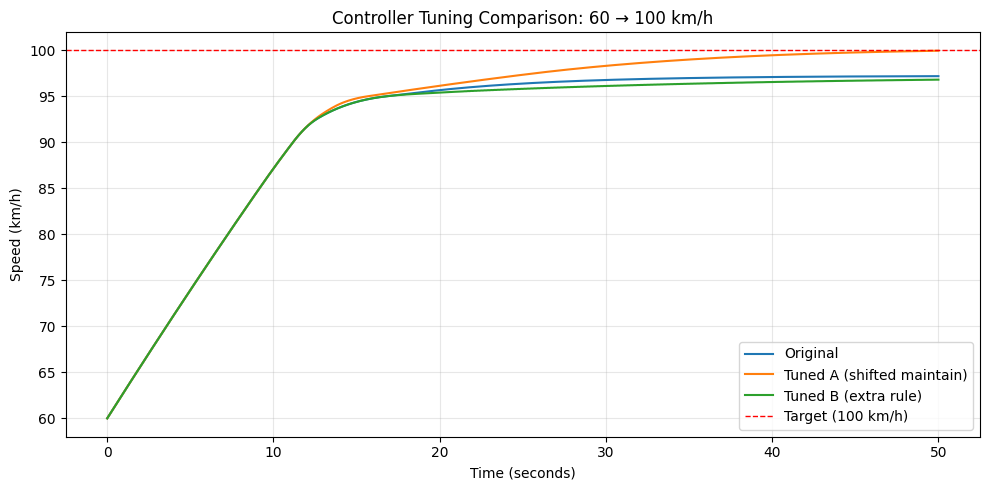

In [14]:
# Overlay comparison using plot_comparison()
plot_comparison(
    result['times'],
    {
        'Original': result['speeds'],
        'Tuned A (shifted maintain)': result_a['speeds'],
        'Tuned B (extra rule)': result_b['speeds'],
    },
    target=100,
    title='Controller Tuning Comparison: 60 → 100 km/h',
)


### 5.4 — Challenge: Beat Tuned A

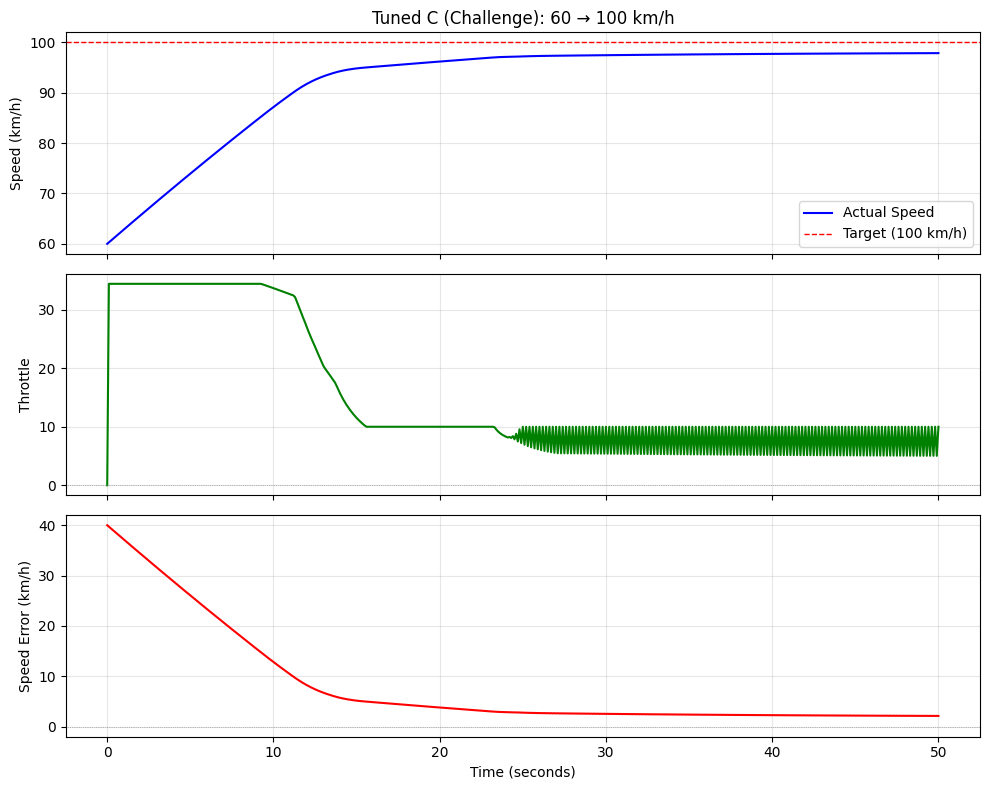

Tuned A — Final speed: 99.97 km/h, SSE: 0.03 km/h
Tuned C — Final speed: 97.88 km/h, SSE: 2.12 km/h


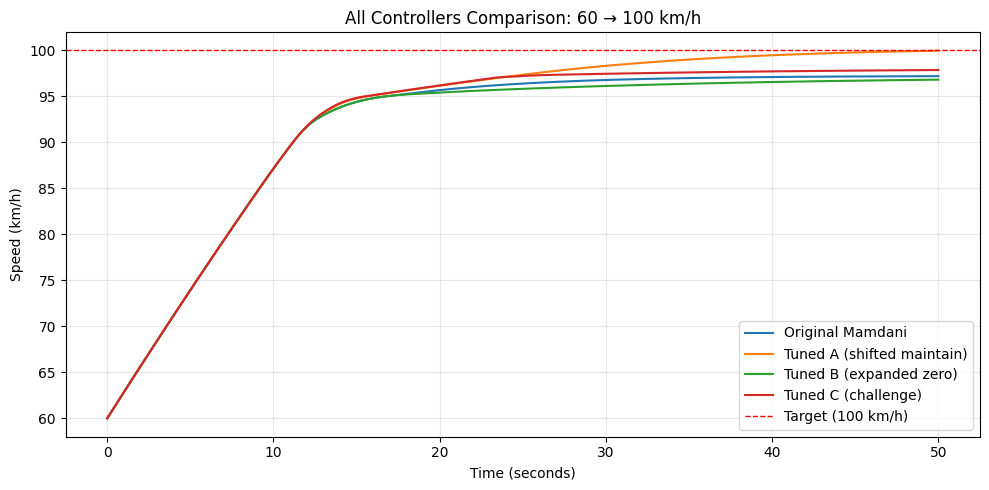

In [15]:
def create_tuned_controller_C():
    """
    Challenge controller combining both strategies:
      - Shifted 'maintain' centroid to compensate drag (Strategy A)
      - Expanded 'zero' rules sensitive to acceleration (Strategy B)
      - Narrower 'zero' speed_error term for tighter dead-band
    """
    engine = fl.Engine(
        name="CruiseControl_TunedC",
        input_variables=[
            fl.InputVariable(
                name="speed_error", minimum=-30, maximum=30,
                terms=[
                    fl.Trapezoid("large_negative", -30, -30, -15, -5),
                    fl.Triangle("small_negative",   -10,  -5,   0),
                    fl.Triangle("zero",               -3,   0,   3),   # narrower dead-band
                    fl.Triangle("small_positive",      0,   5,  10),
                    fl.Trapezoid("large_positive",     5,  15,  30, 30),
                ],
            ),
            fl.InputVariable(
                name="acceleration", minimum=-5, maximum=5,
                terms=[
                    fl.Trapezoid("braking",      -5, -5, -2,  0),
                    fl.Triangle("steady",         -2,  0,  2),
                    fl.Trapezoid("accelerating",   0,  2,  5,  5),
                ],
            ),
        ],
        output_variables=[
            fl.OutputVariable(
                name="throttle", minimum=-50, maximum=50,
                aggregation=fl.Maximum(),
                defuzzifier=fl.Centroid(200),
                terms=[
                    fl.Trapezoid("brake_hard",       -50, -50, -30, -10),
                    fl.Triangle("brake_light",        -20, -10,   0),
                    fl.Triangle("maintain",             2,   8,  14),   # shifted to compensate drag
                    fl.Triangle("accelerate_light",     0,  10,  20),
                    fl.Trapezoid("accelerate_hard",    10,  30,  50, 50),
                ],
            ),
        ],
        rule_blocks=[
            fl.RuleBlock(
                name="rules",
                conjunction=fl.Minimum(),
                disjunction=fl.Maximum(),
                implication=fl.Minimum(),
                activation=fl.General(),
                rules=[
                    # Core directional rules
                    fl.Rule.create("if speed_error is large_negative then throttle is brake_hard"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is accelerating then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is steady then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is braking then throttle is maintain"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is steady then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is accelerating then throttle is maintain"),
                    fl.Rule.create("if speed_error is large_positive then throttle is accelerate_hard"),
                    # Expanded zero rules — react to drag-induced deceleration
                    fl.Rule.create("if speed_error is zero and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is zero and acceleration is steady then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero and acceleration is accelerating then throttle is brake_light"),
                ],
            ),
        ],
    )
    return engine


tuned_c = create_tuned_controller_C()
plant = CarPlant()
result_c = run_simulation(tuned_c, plant, target_speed=100, initial_speed=60, n_steps=500)

plot_simulation(result_c['times'], result_c['speeds'], result_c['throttles'], result_c['errors'],
                target=100, title='Tuned C (Challenge): 60 → 100 km/h')

print(f"Tuned A — Final speed: {result_a['speeds'][-1]:.2f} km/h, "
      f"SSE: {100 - result_a['speeds'][-1]:.2f} km/h")
print(f"Tuned C — Final speed: {result_c['speeds'][-1]:.2f} km/h, "
      f"SSE: {100 - result_c['speeds'][-1]:.2f} km/h")

plot_comparison(
    result['times'],
    {
        'Original Mamdani':           result['speeds'],
        'Tuned A (shifted maintain)': result_a['speeds'],
        'Tuned B (expanded zero)':    result_b['speeds'],
        'Tuned C (challenge)':        result_c['speeds'],
    },
    target=100,
    title='All Controllers Comparison: 60 → 100 km/h',
)
